In [9]:
import os
import json
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import subprocess
import numpy as np
from tqdm import tqdm
from utils import prepare_data, get_variable_encoding_map


# DATA_FILEPATH = 'data/a_estabel_sample.csv'
DATA_FILEPATH = 'tmp/a_estabel.csv' # essa é uma pasta temporária, precisa ser criada e o arquivo copiado para lá
DTYPE_FILEPATH = 'data/estabel_dtypes.json'
VARIABLE_MAP_FILEPATH = 'data/variable_map.json'


dtypes = json.load(open(DTYPE_FILEPATH))

variable_map = json.load(open(VARIABLE_MAP_FILEPATH))
variable_map_df = pd.DataFrame.from_dict(variable_map, orient='index')
variable_map_df = variable_map_df.drop(columns=['condition', 'reference'])

df = pd.read_csv(DATA_FILEPATH, dtype=dtypes)

# Criando o ID de região do pais
estabel_ids = df['V010100'].astype(str)

df['region'] = estabel_ids.str[:1].astype('Int32')
df['uf'] = estabel_ids.str[:2].astype('Int32')
df['city'] = estabel_ids.str[:7].astype('Int32')
df['district'] = estabel_ids.str[:9].astype('Int32')
df['sub_district'] = estabel_ids.str[:13].astype('Int64')

# Removendo valores de identificadores únicos da base
df.drop(['V010100', 'NUM_QUADRA', 'NUM_FACE', 'V010800'], axis=1, inplace=True)

total_samples = df.shape[0]

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Columns: 471 entries, COD_SEQ_ESPECIE to sub_district
dtypes: Float32(175), Int16(70), Int32(6), Int64(1), category(219)
memory usage: 641.4 MB


In [10]:
categorical_variables_map = get_variable_encoding_map(df, variable_map_df)

numerical_variables_map = {
    'variables': list(df.select_dtypes(include=[np.number]).columns),
    'encoding': "minmax",
    'missing_treatment': "zero"
}

X, feature_names, num_features, cat_features = prepare_data(df, numerical_variables_map, categorical_variables_map, variable_map)

X.shape

/home/jonatas/project/ibge-censo-agro-research/utils.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(value, inplace=True)
/home/jonatas/project/ibge-censo-agro-research/utils.py:236: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[col] = df[col].replace(class_to_fill, 0)
/home/jonatas/project/ib

(500000, 1273)

In [11]:
MODELS = {
    "ECOD": {"type": "Probabilistic"}, 
    "COPOD": {"type": "Probabilistic"},
    "PCA": {"type": "Linear"},
    "KPCA": {"type": "Linear"},
    "HBOS": {"type": "Proximity-Based"},
    "CBLOF": {"type": "Proximity-Based"},
    "IForest": {"type": "Outlier Ensembles"},
    "DIF": {"type": "Outlier Ensembles"},
    "R-Graph": {"type": "Graph-based"},
    "LUNAR": {"type": "Graph-based"},
    "VAE": {"type": "Neural Networks"},
    "ALAD": {"type": "Neural Networks"},
}

TMP_MEMORY_LOG_PATH = "tmp/memory_log.txt"

RESULTS_PATH = "tmp/check_recursos_results.json"

results = [] if not os.path.exists(RESULTS_PATH) else json.load(open(RESULTS_PATH))

experiments = list(itertools.product(MODELS.keys(), [2, 3, 5], [0.001, 0.01, 0.1, 0.2, 0.5, 1]))
experiments.sort(key=lambda x: (x[0], x[1], x[2]))

for model_name, seed, dataset_ratio in (pbar := tqdm(experiments)):

    if os.path.exists(TMP_MEMORY_LOG_PATH):
        os.remove(TMP_MEMORY_LOG_PATH)

    pbar.set_description(f"Seed: {seed}, Ratio: {dataset_ratio}, Model: {model_name}")

    model_info = MODELS[model_name]
    model_type = model_info["type"]

    # check if this configuration was already run
    if any(r for r in results if r["model"] == model_name and r["dataset_ratio"] == dataset_ratio and r["seed"] == seed):
        # print(f"Skipping already run configuration: model={model_name}, dataset_ratio={dataset_ratio}, seed={seed}")
        continue

    start_time = time.time()

    cmd = f"mprof run --output={TMP_MEMORY_LOG_PATH} check_recursos.py --model={model_name} --dataset_ratio={dataset_ratio} \
                --seed={seed} --data_filepath={DATA_FILEPATH} --dtype_filepath={DTYPE_FILEPATH} \
                --variable_map_filepath={VARIABLE_MAP_FILEPATH} > /dev/null"

    # r = os.system(cmd)
    # print(r)

    try:
        output = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, timeout=1800)
        output_msg = output.decode()
    except Exception as e:
        output_msg = str(e)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    # get peak memory usage
    with open(TMP_MEMORY_LOG_PATH, 'r') as f:
        lines = f.readlines()
        mem_usages = [float(line.split()[1]) for line in lines if line.startswith('MEM')]
        peak_memory = max(mem_usages) if mem_usages else 0.0

    result = {
        "model": model_name,
        "type": model_type,
        "dataset_ratio": dataset_ratio,
        "num_samples": int(total_samples * dataset_ratio),
        "seed": seed,
        "time_in_seconds": elapsed_time,
        "peak_memory_in_mb": peak_memory,
        "output_msg": output_msg,
    }
    results.append(result)
    # print(f"Result: {result}")

    # save results after each run
    with open(RESULTS_PATH, 'w') as f:
        json.dump(results, f, indent=4)


Seed: 5, Ratio: 1, Model: VAE: 100%|██████████| 216/216 [1:51:56<00:00, 31.10s/it]    


In [12]:
results_df = pd.DataFrame(results)
results_df['peak_memory_in_gb'] = results_df['peak_memory_in_mb'] / 1024
results_df['time_in_minutes'] = results_df['time_in_seconds'] / 60
results_df

,model,type,dataset_ratio,num_samples,seed,time_in_seconds,peak_memory_in_mb,output_msg,peak_memory_in_gb,time_in_minutes
0,ALAD,Neural Networks,0.001,500,2,41.007566,11818.359375,,11.541367,0.683459
1,ALAD,Neural Networks,0.010,5000,2,42.307553,12023.906250,,11.742096,0.705126
2,ALAD,Neural Networks,0.100,50000,2,58.583106,11799.152344,,11.522610,0.976385
3,ALAD,Neural Networks,0.500,250000,2,131.508200,16944.679688,,16.547539,2.191803
4,ALAD,Neural Networks,1.000,500000,2,223.707090,26646.929688,,26.022392,3.728452
...,...,...,...,...,...,...,...,...,...,...
211,VAE,Neural Networks,0.500,250000,2,1580.724535,11864.699219,,11.586620,26.345409
212,VAE,Neural Networks,0.100,50000,3,604.130059,11803.210938,,11.526573,10.068834
213,VAE,Neural Networks,0.200,100000,3,851.215973,11803.285156,,11.526646,14.186933
214,VAE,Neural Networks,0.500,250000,3,1674.685417,12122.453125,,11.838333,27.911424


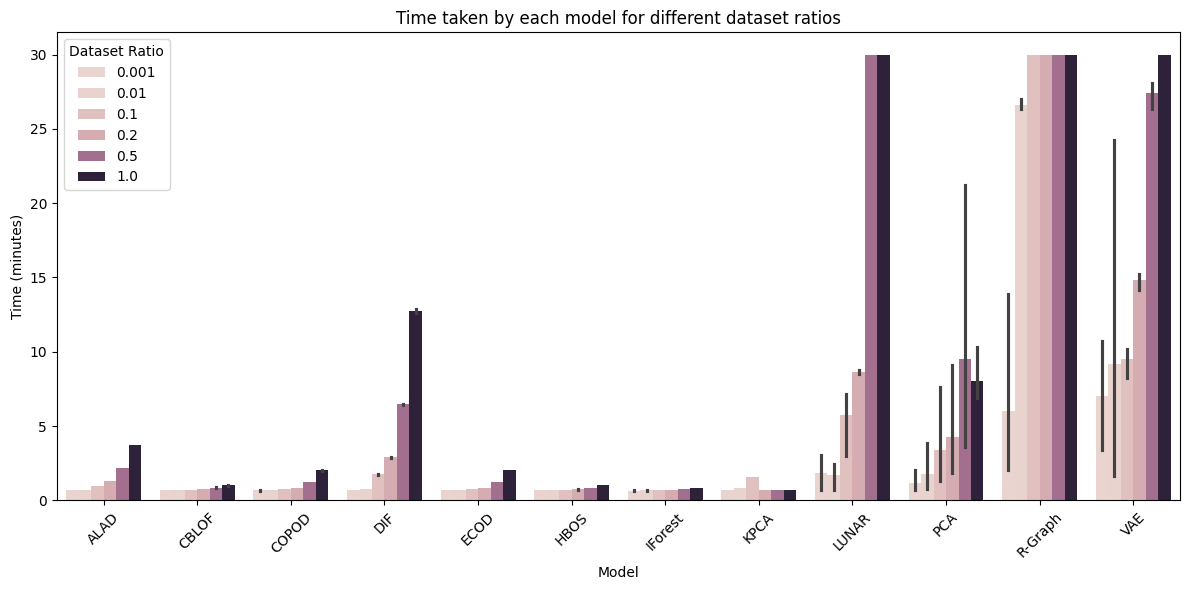

In [13]:
# time bar
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='model', y='time_in_minutes', hue='dataset_ratio')
plt.title('Time taken by each model for different dataset ratios')
plt.ylabel('Time (minutes)')
plt.xlabel('Model')
plt.legend(title='Dataset Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

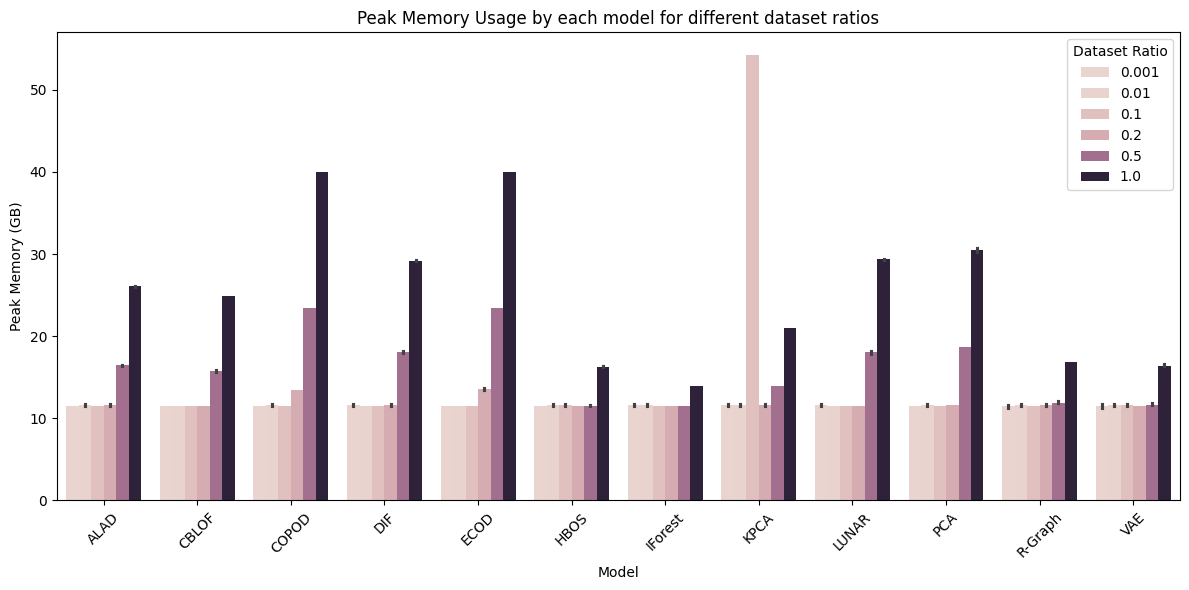

In [14]:
# memory bar
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='model', y='peak_memory_in_gb', hue='dataset_ratio')
plt.title('Peak Memory Usage by each model for different dataset ratios')
plt.ylabel('Peak Memory (GB)')
plt.xlabel('Model')
plt.legend(title='Dataset Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

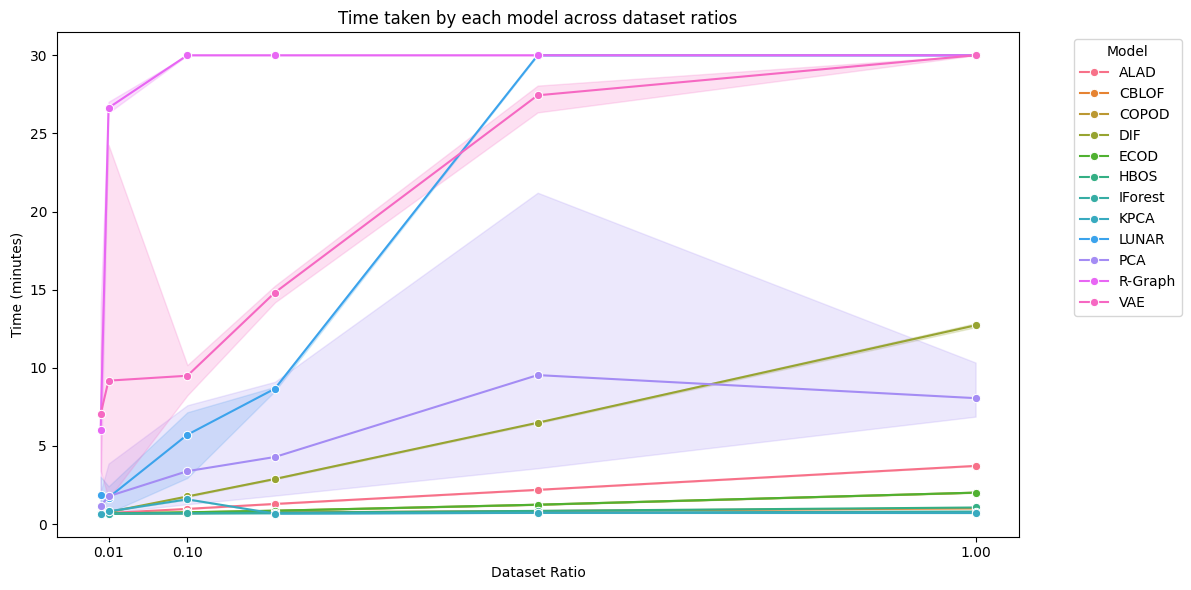

In [15]:

# plot line chart (time)
plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='dataset_ratio', y='time_in_minutes', hue='model', marker='o')
plt.title('Time taken by each model across dataset ratios')
plt.ylabel('Time (minutes)')
plt.xlabel('Dataset Ratio')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([0.01, 0.1, 1])
plt.tight_layout()
plt.show()


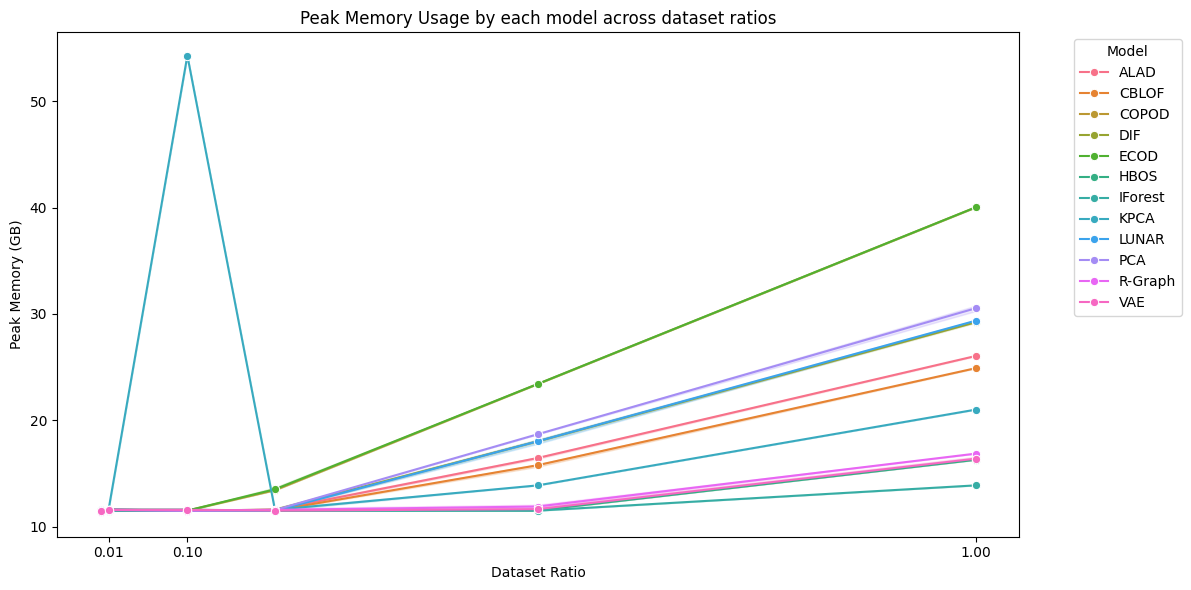

In [16]:

# plot line chart (memory)
plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='dataset_ratio', y='peak_memory_in_gb', hue='model', marker='o')
plt.title('Peak Memory Usage by each model across dataset ratios')
plt.ylabel('Peak Memory (GB)')
plt.xlabel('Dataset Ratio')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([0.01, 0.1, 1])
plt.tight_layout()
plt.show()